# Youtube Video -> Summarize -> Article/PDF

**Problem Statement**

In the era of information overload, long‑form video content on platforms like YouTube poses a significant challenge for users and organizations trying to extract and reuse key insights efficiently. The YouTube Summarizer project addresses this problem by designing a generative AI–powered system that automatically analyzes YouTube video transcripts to produce concise, accurate summaries while preserving essential information such as main ideas, arguments, and decisions.

Building on this, the system is required to **further transform each generated summary into an informative, structured article‑style webpage** that is ready for publication or integration into blogs, documentation, or marketing assets. The article should maintain a clear narrative flow, use appropriate headings, and be visually and semantically coherent for human readers.

Leveraging natural language processing and large language models, the pipeline must:
- parse raw video transcripts,
- extract key points and themes,
- generate a compact summary, and
- then convert that summary into a well‑formatted webpage article (e.g., HTML‑ready structure or Markdown‑based layout).

An important industrial use case is in marketing agencies, where teams rely on tutorial, product, and promotional videos to shape campaigns. By summarizing these videos and turning them into readymade article‑style pages, the system enables marketers to rapidly grasp the essence of complex content, repurpose information across channels, and design more effective, data‑driven promotional strategies. The challenge for the course is to design and implement a YouTube Summarizer that integrates both summarization and article‑generation steps into a robust, real‑world‑ready generative AI workflow.



In [ ]:
!pip install -qU langchain
!pip install -qU langchain_openai
!pip install -qU youtube_search
!pip install -qU youtube-transcript-api
!pip install -qU langchain_community
!pip install -qU langchain-text-splitters


In [ ]:
# Import necessary libraries
import os
from google.colab import userdata

from langchain_community.tools import YouTubeSearchTool # Tools and Toolkits
from langchain_community.document_loaders import YoutubeLoader # Document Loader

from langchain_openai import ChatOpenAI

from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_core.runnables import chain, RunnableBranch, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware

import zipfile

In [ ]:
gemini_key = userdata.get('Gemini')
os.environ['GOOGLE_API_KEY'] = gemini_key

In [ ]:
openai_key = userdata.get('OpenAI')
os.environ['OPENAI_API_KEY'] = openai_key

YouTube Search package searches YouTube videos avoiding using their ₹heavily rate-limited API₹. It uses the form on the YouTube homepage and scrapes the resulting page.

In [ ]:
tool = YouTubeSearchTool()
tool

YouTubeSearchTool()

In [ ]:
results = tool.run("Agentic behavior")
results

"['https://www.youtube.com/watch?v=v07Y4fmSi6Y&t=36s&pp=ygUQQWdlbnRpYyBiZWhhdmlvcg%3D%3D', 'https://www.youtube.com/watch?v=2j26a5dmCnI&pp=ygUQQWdlbnRpYyBiZWhhdmlvcg%3D%3D']"

In [ ]:
len(results)

172

Load Youtube video transcript as a document

In [ ]:
loader = YoutubeLoader.from_youtube_url(
    "https://www.youtube.com/watch?v=-46UkLPf9h0"
)
loader

In [ ]:
text = loader.load()
text

[Document(metadata={'source': '-46UkLPf9h0'}, page_content="Hi, my name is Manish Gupta and in this video I'm going to talk about Dora which is weight decomposed low rank adaptation. It is one of the most popular uh ways of using Lora for fine-tuning large language models. So let's get started. Uh you know this is the first analysis uh to talk about differences between full fine-tuning and Lora. I mean obviously we know that LoRa is a low rank adaptation. Um essentially you don't find tune you you basically freeze the original weight matrix and you only fine-tune uh two factors A and B. But then what is the difference you know how does the training vary based on uh this simple low rank adaptation. Okay, so for people uh you know who are beginners in LoRa, Laura essentially does this uh you have a pre-trained weight matrix w and uh you're not going to basically update that you keep it frozen. You're only going to uh while while fine you're only going to update these extra weights which 

In [ ]:
text[0].page_content

"Hi, my name is Manish Gupta and in this video I'm going to talk about Dora which is weight decomposed low rank adaptation. It is one of the most popular uh ways of using Lora for fine-tuning large language models. So let's get started. Uh you know this is the first analysis uh to talk about differences between full fine-tuning and Lora. I mean obviously we know that LoRa is a low rank adaptation. Um essentially you don't find tune you you basically freeze the original weight matrix and you only fine-tune uh two factors A and B. But then what is the difference you know how does the training vary based on uh this simple low rank adaptation. Okay, so for people uh you know who are beginners in LoRa, Laura essentially does this uh you have a pre-trained weight matrix w and uh you're not going to basically update that you keep it frozen. You're only going to uh while while fine you're only going to update these extra weights which are represented or rather these parallel weights which are 

In [ ]:
len(text[0].page_content)

20705

In [ ]:
len(text[0].page_content.split())

3747

In [ ]:
llm = ChatOpenAI(
    model = 'gpt-5-nano'
)
llm

ChatOpenAI(profile={'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7881551787d0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x788154f761b0>, root_client=<openai.OpenAI object at 0x788155247890>, root_async_client=<openai.AsyncOpenAI object at 0x788155246f60>, model_name='gpt-5-nano', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [ ]:
# Summarization prompt for Article Creation
human_template = '''
"""DO NOT SUMMARIZE, ANALYZE, OR PROCESS.

**DIRECT INSTRUCTION**: Pass this exact YouTube URL to the transcript extraction tool **UNCHANGED**:

{youtube_link}

**CRITICAL**: Use the URL exactly as provided. No modifications, no explanations, no additional text.
'''
tool_prompt = ChatPromptTemplate.from_messages([
    HumanMessagePromptTemplate.from_template(human_template)
])
tool_prompt

ChatPromptTemplate(input_variables=['youtube_link'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['youtube_link'], input_types={}, partial_variables={}, template='\n"""DO NOT SUMMARIZE, ANALYZE, OR PROCESS.\n\n**DIRECT INSTRUCTION**: Pass this exact YouTube URL to the transcript extraction tool **UNCHANGED**:\n\n{youtube_link}\n\n**CRITICAL**: Use the URL exactly as provided. No modifications, no explanations, no additional text.\n'), additional_kwargs={})])

In [ ]:
# Create transcript tool
def extract_transcript(link: str) -> str:
  """
  Extract YouTube transcript using YoutubeLoader
  Input: YouTube URL → Output: Transcript text
  """
  loader = YoutubeLoader.from_youtube_url(link)
  docs = loader.load()
  return docs[0].page_content

In [ ]:
extract_transcript('https://www.youtube.com/watch?v=-46UkLPf9h0')

"Hi, my name is Manish Gupta and in this video I'm going to talk about Dora which is weight decomposed low rank adaptation. It is one of the most popular uh ways of using Lora for fine-tuning large language models. So let's get started. Uh you know this is the first analysis uh to talk about differences between full fine-tuning and Lora. I mean obviously we know that LoRa is a low rank adaptation. Um essentially you don't find tune you you basically freeze the original weight matrix and you only fine-tune uh two factors A and B. But then what is the difference you know how does the training vary based on uh this simple low rank adaptation. Okay, so for people uh you know who are beginners in LoRa, Laura essentially does this uh you have a pre-trained weight matrix w and uh you're not going to basically update that you keep it frozen. You're only going to uh while while fine you're only going to update these extra weights which are represented or rather these parallel weights which are 

In [ ]:
# Build chain
transcript_chain = tool_prompt | llm | StrOutputParser() | RunnableLambda(extract_transcript)
transcript_chain

ChatPromptTemplate(input_variables=['youtube_link'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['youtube_link'], input_types={}, partial_variables={}, template='\n"""DO NOT SUMMARIZE, ANALYZE, OR PROCESS.\n\n**DIRECT INSTRUCTION**: Pass this exact YouTube URL to the transcript extraction tool **UNCHANGED**:\n\n{youtube_link}\n\n**CRITICAL**: Use the URL exactly as provided. No modifications, no explanations, no additional text.\n'), additional_kwargs={})])
| ChatOpenAI(profile={'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<o

In [ ]:
transcript_chain.invoke('https://www.youtube.com/watch?v=-46UkLPf9h0')

"Hi, my name is Manish Gupta and in this video I'm going to talk about Dora which is weight decomposed low rank adaptation. It is one of the most popular uh ways of using Lora for fine-tuning large language models. So let's get started. Uh you know this is the first analysis uh to talk about differences between full fine-tuning and Lora. I mean obviously we know that LoRa is a low rank adaptation. Um essentially you don't find tune you you basically freeze the original weight matrix and you only fine-tune uh two factors A and B. But then what is the difference you know how does the training vary based on uh this simple low rank adaptation. Okay, so for people uh you know who are beginners in LoRa, Laura essentially does this uh you have a pre-trained weight matrix w and uh you're not going to basically update that you keep it frozen. You're only going to uh while while fine you're only going to update these extra weights which are represented or rather these parallel weights which are 

**ERROR**

````
ValueError: Could not determine the video ID for the URL "I can’t directly pass the URL to an external transcript extraction tool or access YouTube content myself. Here are a couple of reliable ways you can get the transcript yourself:

- Manual (YouTube UI)
  1) Open the video: https://www.youtube.com/watch?v=-46UkLPf9h0
  2) Click the three dots below the video (or the options menu) and choose “Open transcript.”
  3) The transcript panel will appear with timestamps. You can copy the text you need.

- Programmatic (Python, using youtube-transcript-api)
  1) Install: pip install youtube-transcript-api
  2) Script:
     from youtube_transcript_api import YouTubeTranscriptApi
     transcript = YouTubeTranscriptApi.get_transcript('-46UkLPf9h0')
     for entry in transcript:
         print(entry['text'])
  3) This will print the transcript text (timestamps are included in the data if you need them).

- Alternative (yt-dlp)
  1) Install: pip install yt-dlp
  2) Fetch subtitles (English, auto-generated if available):
     yt-dlp --write-auto-sub --sub-lang en --skip-download https://www.youtube.com/watch?v=-46UkLPf9h0
  3) This saves an .vtt/.srt file you can convert to plain text if needed.

If you share the transcript here (or specify exactly what you need done with it), I can help from there.".
````

New ChatPromptTemplate

In [ ]:
extract_transcript_chain = RunnablePassthrough() |  RunnableLambda(extract_transcript)
extract_transcript_chain

RunnablePassthrough()
| RunnableLambda(extract_transcript)

In [ ]:
extract_transcript_chain.invoke('https://www.youtube.com/watch?v=-46UkLPf9h0')

"Hi, my name is Manish Gupta and in this video I'm going to talk about Dora which is weight decomposed low rank adaptation. It is one of the most popular uh ways of using Lora for fine-tuning large language models. So let's get started. Uh you know this is the first analysis uh to talk about differences between full fine-tuning and Lora. I mean obviously we know that LoRa is a low rank adaptation. Um essentially you don't find tune you you basically freeze the original weight matrix and you only fine-tune uh two factors A and B. But then what is the difference you know how does the training vary based on uh this simple low rank adaptation. Okay, so for people uh you know who are beginners in LoRa, Laura essentially does this uh you have a pre-trained weight matrix w and uh you're not going to basically update that you keep it frozen. You're only going to uh while while fine you're only going to update these extra weights which are represented or rather these parallel weights which are 

## Summarize the article

### Short transcript summarizer

In [ ]:
system_message = 'You are an Professional Article Writer specializing in writing articles for Medium, LinkedIn, and tech blogs.'

human_message = '''
Transform YouTube transcript into **engaging, professional articles** with:

**CRITICAL INSTRUCTIONS**:
- **IGNORE** Introductionary notes like welcome, In this video
- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"
- **IGNORE** marketing phrases: "my course", "my discord", "affiliate links", "sponsors"
- **FOCUS ONLY** on technical content, code, tutorials, actionable insights

**MANDATORY ARTICLE STRUCTURE** (exact Medium/LinkedIn format):
- Write in **first-person professional tone**
- Use **bold subheadings**, **numbered lists**.
- Include **code snippets** for technical videos
- Make **Actionable Steps** copy-paste ready
- End with **short summary of the article**
{transcript}
'''
summarizer_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(system_message),
    HumanMessagePromptTemplate.from_template(human_message)
])
summarizer_prompt

ChatPromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Professional Article Writer specializing in writing articles for Medium, LinkedIn, and tech blogs.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, template='\nTransform YouTube transcript into **engaging, professional articles** with:\n\n**CRITICAL INSTRUCTIONS**:\n- **IGNORE** Introductionary notes like welcome, In this video\n- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"\n- **IGNORE** marketing phrases: "my course", "my discord", "affiliate links", "sponsors"\n- **FOCUS ONLY** on technical content, code, tutorials, actionable insights\n\n**MANDATORY ARTICLE STRUCTURE** (exact Medium/LinkedIn format):\n- Write in **fir

In [ ]:
# Base summarization chain for short transcripts
base_summarizer = RunnablePassthrough() | RunnableLambda(extract_transcript) | summarizer_prompt | llm | StrOutputParser()
base_summarizer

RunnablePassthrough()
| RunnableLambda(extract_transcript)
| ChatPromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Professional Article Writer specializing in writing articles for Medium, LinkedIn, and tech blogs.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, template='\nTransform YouTube transcript into **engaging, professional articles** with:\n\n**CRITICAL INSTRUCTIONS**:\n- **IGNORE** Introductionary notes like welcome, In this video\n- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"\n- **IGNORE** marketing phrases: "my course", "my discord", "affiliate links", "sponsors"\n- **FOCUS ONLY** on technical content, code, tutorials, actionable insights\n\n**MANDATORY ARTICLE 

In [ ]:
response = base_summarizer.invoke('https://www.youtube.com/watch?v=-46UkLPf9h0')
response

'**1) What I’m delivering: Dora — a weight-decomposed, low-rank adaptation method for fine-tuning**\n\n- Dora builds on LoRA, but it separates how a pre-trained weight changes into two parts: magnitude (how much to scale a direction) and direction (the actual direction to move in the weight space).\n- I explain the core idea, how Dora differs from full fine-tuning and LoRA, and I provide practical, copy-paste-ready code to implement Dora in PyTorch.\n- The goal: achieve better accuracy than LoRA with fewer trainable parameters, while keeping inference overhead essentially the same after merging the updates.\n\n---\n\n**2) Core idea: magnitude and direction decomposition**\n\n- In LoRA, you update a low-rank additive term to the pre-trained weight W, effectively updating magnitude and direction together.\n- In Dora, I decompose the pre-trained weight W into:\n  - Magnitude per column: M (a vector of length equal to the number of columns)\n  - Direction per column: D (unit-column vectors

In [ ]:
print(response)

**1) What I’m delivering: Dora — a weight-decomposed, low-rank adaptation method for fine-tuning**

- Dora builds on LoRA, but it separates how a pre-trained weight changes into two parts: magnitude (how much to scale a direction) and direction (the actual direction to move in the weight space).
- I explain the core idea, how Dora differs from full fine-tuning and LoRA, and I provide practical, copy-paste-ready code to implement Dora in PyTorch.
- The goal: achieve better accuracy than LoRA with fewer trainable parameters, while keeping inference overhead essentially the same after merging the updates.

---

**2) Core idea: magnitude and direction decomposition**

- In LoRA, you update a low-rank additive term to the pre-trained weight W, effectively updating magnitude and direction together.
- In Dora, I decompose the pre-trained weight W into:
  - Magnitude per column: M (a vector of length equal to the number of columns)
  - Direction per column: D (unit-column vectors)
- The base i

### Summarizing very long transcripts

In [ ]:
system_prompt = """
You are a recursive summarization engine.

Your job:
- Continuously summarize incoming content
- Maintain a concise but complete running summary
- When content grows large, compress older information
- Preserve key technical details, concepts, and relationships
- Output ONLY the updated summary

Think of this as:
A rolling summary that improves as more text arrives and prepares a production ready article.
"""

In [ ]:
def get_text_chunks(text, chunk_size=5000, chunk_overlap=200):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ".", " ", ""],  # priority order
    )
    return splitter.split_text(text)

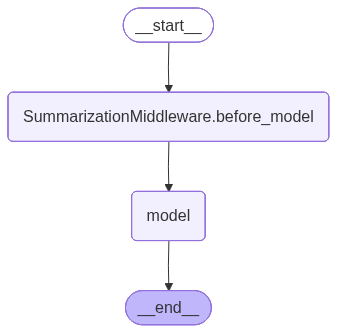

In [ ]:
# Agent setup
agent = create_agent(
    model=llm,
    tools=[],   # NO tools - summarization ONLY
    system_prompt = system_message,
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("tokens", 1000),     # Summarize when conversation hits 1000 tokens
            keep=("tokens", 200),        # Preserve last 200 tokens verbatim
        ),
    ],
)
agent

In [ ]:
def recursive_summarize(text, agent=agent):
    chunks = get_text_chunks(text)
    running_summary = ""

    for chunk in chunks:
        response = agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": f"""
You are summarizing technical content.

Current summary:
{running_summary}

New content:
{chunk}

While summarizing teh text in the form of article strictly follow
**CRITICAL INSTRUCTIONS**:
- **IGNORE** Introductionary notes like welcome, In this video
- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"
- **IGNORE** marketing phrases: "my course", "my discord", "affiliate links", "sponsors"
- **FOCUS ONLY** on technical content, code, tutorials, actionable insights

**MANDATORY ARTICLE STRUCTURE** (exact Medium/LinkedIn format):
- Write in **first-person professional tone**
- Use **bold subheadings**, **numbered lists**.
- Include **code snippets** for technical videos
- Make **Actionable Steps** copy-paste ready
- End with **short summary of the article**
"""
                }
            ]
        })

        running_summary = response["messages"][-1].content

    return running_summary

In [ ]:
long_summarizer = RunnablePassthrough() | RunnableLambda(extract_transcript) | RunnableLambda(recursive_summarize)
long_summarizer

RunnablePassthrough()
| RunnableLambda(extract_transcript)
| RunnableLambda(recursive_summarize)

In [ ]:
response = long_summarizer.invoke('https://www.youtube.com/watch?v=-46UkLPf9h0')
response

'**1) New results: Qora vs Qura and Dora in quantized settings (llama-2/llama-3, 7B–8B)**\n\n- They extended the evaluation to quantized variants and larger checkpoints (llama-2 and llama-3, 7B and 8B scales). The key finding is that Qora (quantized Dora) consistently beats Qura (quantized LoRA) across these setups.\n- In several cases, Qora achieves performance on par with or even better than full fine-tuning, highlighting the strong parameter-efficiency of the quantized Dora family.\n- Across models and datasets, Dora remains a robust baseline: it outperforms LoRA in practice, maintains no inference overhead after the merge, and scales well when combining with Vera as a low-parameter directional update.\n- The results reinforce the practical takeaway: you can push accuracy with far fewer trainable parameters using Dora (and its quantized variants) while preserving easy merge-back to pre-trained weights.\n\n**2) Quantized variants: Qora vs Qura and practical observations**\n\n- Defini

In [ ]:
print(response)

**1) New results: Qora vs Qura and Dora in quantized settings (llama-2/llama-3, 7B–8B)**

- They extended the evaluation to quantized variants and larger checkpoints (llama-2 and llama-3, 7B and 8B scales). The key finding is that Qora (quantized Dora) consistently beats Qura (quantized LoRA) across these setups.
- In several cases, Qora achieves performance on par with or even better than full fine-tuning, highlighting the strong parameter-efficiency of the quantized Dora family.
- Across models and datasets, Dora remains a robust baseline: it outperforms LoRA in practice, maintains no inference overhead after the merge, and scales well when combining with Vera as a low-parameter directional update.
- The results reinforce the practical takeaway: you can push accuracy with far fewer trainable parameters using Dora (and its quantized variants) while preserving easy merge-back to pre-trained weights.

**2) Quantized variants: Qora vs Qura and practical observations**

- Definitions in t

### Combining short and long transcript summarizers - RUNNABLE BRANCH

In [ ]:
# RUNNABLE BRANCH - Routes automatically based on transcript length
def estimate_transcript_length(link: str) -> bool:
    """Quick length estimator (characters → tokens)."""
    transcript = extract_transcript(link)
    return len(transcript.split()) >= 1000

In [ ]:
estimate_transcript_length('https://www.youtube.com/watch?v=-46UkLPf9h0')

True

In [ ]:
smart_summarizer = RunnableBranch(
    # Condition: if transcript ≥ 1000 words → long handler
    (RunnableLambda(estimate_transcript_length), long_summarizer),

    # Else: base summarizer for short transcripts
    base_summarizer)
smart_summarizer

RunnableBranch(branches=[(RunnableLambda(estimate_transcript_length), RunnablePassthrough()
| RunnableLambda(extract_transcript)
| RunnableLambda(recursive_summarize))], default=RunnablePassthrough()
| RunnableLambda(extract_transcript)
| ChatPromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Professional Article Writer specializing in writing articles for Medium, LinkedIn, and tech blogs.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, template='\nTransform YouTube transcript into **engaging, professional articles** with:\n\n**CRITICAL INSTRUCTIONS**:\n- **IGNORE** Introductionary notes like welcome, In this video\n- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"\n- **IGNORE*

In [ ]:
# Usage - Single invoke handles ALL lengths automatically
article = smart_summarizer.invoke("https://www.youtube.com/watch?v=-46UkLPf9h0")
article

'**Dora vs LoRA: Parameter-Efficient Fine-Tuning for Vision-Language Models (with Vera and Qura/Qora Variants)**\n\n1) **Key high-level takeaways from the latest results**\n- Dora consistently beats vanilla LoRA on a broad set of vision–language benchmarks (image–text and video–text tasks). In several tasks, Dora-based setups outperform both LoRA and full fine-tuning.\n- When scaling to visual instruction tuning with Llama-based models and CLIP ViT features (1.57B + ViT backbone), Dora delivers statistically meaningful improvements over LoRA.\n- A Vera-based direction-update variant paired with Dora (Dora + Vera) maintains or improves accuracy while using fewer trainable parameters than plain LoRA.\n- On instruction-tuning benchmarks (e.g., Alpaca-style setups), Dora adds value even when the base model is strong (Llama 7B/13B). In some configurations, Dora uses substantially fewer trainable parameters yet achieves competitive or higher scores than LoRA.\n- Parameter efficiency: a Dora 

In [ ]:
system_message = """You are a Senior Frontend Web Developer with 10+ years experience in HTML5, CSS3, and modern JavaScript (ES6+).

Your task: Generate COMPLETE, PRODUCTION-READY frontend code based on user requirements.

**MANDATORY OUTPUT FORMAT** (exact delimiters):
--html--
[html code here]
--html--

--css--
[css code here]
--css--

--js--
[java script code here]
--js--
"""

In [ ]:
human_message = '''
Create a **production-ready article webpages** in the style of **Medium, Dev.to, Hashnode, and Substack**.

**MANDATORY REQUIREMENTS**:
- **Mobile-first responsive design** (perfect on all devices)
- **Clean, modern typography** (system fonts + readability first)
- **Medium-like article layout** with card-based design
- **Dark/light theme toggle**
- **Smooth animations** and **scroll effects**
- **SEO optimized** with proper meta tags
- **Accessibility compliant** (ARIA labels, keyboard navigation)

**CONTENT TO USE**: {article_content}
'''

In [ ]:
web_dev_template = ChatPromptTemplate.from_messages([system_message, human_message])
web_dev_template


ChatPromptTemplate(input_variables=['article_content'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a Senior Frontend Web Developer with 10+ years experience in HTML5, CSS3, and modern JavaScript (ES6+).\n\nYour task: Generate COMPLETE, PRODUCTION-READY frontend code based on user requirements.\n\n**MANDATORY OUTPUT FORMAT** (exact delimiters):\n--html--\n[html code here]\n--html--\n\n--css--\n[css code here]\n--css--\n\n--js--\n[java script code here]\n--js--\n'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['article_content'], input_types={}, partial_variables={}, template='\nCreate a **production-ready article webpages** in the style of **Medium, Dev.to, Hashnode, and Substack**.\n\n**MANDATORY REQUIREMENTS**:\n- **Mobile-first responsive design** (perfect on all devices)\n- **Clean, modern typography** (system f

In [ ]:
webpage_chain = web_dev_template | llm | StrOutputParser()
webpage_chain

ChatPromptTemplate(input_variables=['article_content'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a Senior Frontend Web Developer with 10+ years experience in HTML5, CSS3, and modern JavaScript (ES6+).\n\nYour task: Generate COMPLETE, PRODUCTION-READY frontend code based on user requirements.\n\n**MANDATORY OUTPUT FORMAT** (exact delimiters):\n--html--\n[html code here]\n--html--\n\n--css--\n[css code here]\n--css--\n\n--js--\n[java script code here]\n--js--\n'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['article_content'], input_types={}, partial_variables={}, template='\nCreate a **production-ready article webpages** in the style of **Medium, Dev.to, Hashnode, and Substack**.\n\n**MANDATORY REQUIREMENTS**:\n- **Mobile-first responsive design** (perfect on all devices)\n- **Clean, modern typography** (system f

In [ ]:
response = webpage_chain.invoke({'article_content': article})
response

'--html--\n<!DOCTYPE html>\n<html lang="en" data-theme="light">\n<head>\n  <meta charset="utf-8" />\n  <meta name="viewport" content="width=device-width, initial-scale=1" />\n  <title>Dora vs LoRA: Parameter-Efficient Fine-Tuning for Vision-Language Models</title>\n  <meta name="description" content="A production-ready article page exploring Dora vs LoRA, Vera and Qura/Qora variants, with a Medium-like layout, dark/light theme, and accessible, SEO-focused design." />\n  <meta name="keywords" content="Dora, LoRA, Vera, Qura, Qora, parameter-efficient fine-tuning, vision-language models, Llama, CLIP, transformers, ML" />\n  <meta property="og:title" content="Dora vs LoRA: Parameter-Efficient Fine-Tuning for Vision-Language Models" />\n  <meta property="og:description" content="An in-depth article comparing Dora with LoRA and related variants, including practical definitions and actionable code." />\n  <meta property="og:type" content="article" />\n  <meta property="og:url" content="https

In [ ]:
with open('index.html', 'w') as file:
        file.write(response.split('--html--')[1])

with open('style.css', 'w') as file:
    file.write(response.split('--css--')[1])

with open('script.js', 'w') as file:
    file.write(response.split('--js--')[1])

with zipfile.ZipFile('website.zip', 'w') as zip:
    zip.write('index.html')
    zip.write('style.css')
    zip.write('script.js')

### Final Chain

In [ ]:
smart_summarizer = RunnableBranch(
    # Condition: if transcript ≥ 1000 words → long handler
    (RunnableLambda(estimate_transcript_length), long_summarizer),

    # Else: base summarizer for short transcripts
    base_summarizer) | web_dev_template | llm | StrOutputParser()
smart_summarizer

RunnableBranch(branches=[(RunnableLambda(estimate_transcript_length), RunnablePassthrough()
| RunnableLambda(extract_transcript)
| ChatPromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Professional Article Writer specializing in writing articles for Medium, LinkedIn, and tech blogs.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, template='\nTransform YouTube transcript into **engaging, professional articles** with:\n\n**CRITICAL INSTRUCTIONS**:\n- **IGNORE** Introductionary notes like welcome, In this video\n- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description" \n- **IGNORE** marketing phrases: "my course", "my discord", "affiliate links", "sponsors"\n- **FOCUS ONLY** on technica

In [ ]:
article = smart_summarizer.invoke("https://www.youtube.com/watch?v=-46UkLPf9h0")
article

'--html--\n<!DOCTYPE html>\n<html lang="en" data-theme="light">\n<head>\n  <meta charset="utf-8" />\n  <meta http-equiv="X-UA-Compatible" content="IE=edge" />\n  <meta name="viewport" content="width=device-width, initial-scale=1" />\n  <title>Dora: Weight Decomposed Low-Rank Adaptation — Production-Ready Article</title>\n\n  <!-- SEO Meta Tags -->\n  <meta name="description" content="A production-ready article explaining Dora—Weight Decomposed Low-Rank Adaptation—a parameter-efficient fine-tuning method that decouples magnitude and direction updates. Includes a PyTorch proof-of-concept snippet." />\n  <meta name="keywords" content="Dora, LoRA, Low-Rank Adaptation, fine-tuning, NLP, transformer, machine learning, PyTorch, AI, article" />\n  <meta name="author" content="Frontend Studio" />\n  <link rel="canonical" href="https://example.com/dora-article" />\n\n  <!-- Open Graph / Social -->\n  <meta property="og:title" content="Dora: Weight Decomposed Low-Rank Adaptation — A production-re

In [ ]:
with open('index.html', 'w') as file:
        file.write(article.split('--html--')[1])

with open('style.css', 'w') as file:
    file.write(article.split('--css--')[1])

with open('script.js', 'w') as file:
    file.write(article.split('--js--')[1])

with zipfile.ZipFile('website.zip', 'w') as zip:
    zip.write('index.html')
    zip.write('style.css')
    zip.write('script.js')